<a href="https://colab.research.google.com/github/karkhutmaria/KarkhutM_NLP_hw/blob/main/%D0%9A%D0%B0%D1%80%D1%85%D1%83%D1%82_%D0%9C_%2C_%D0%B0%D0%B3%D0%B5%D0%BD%D1%82%D0%BD%D0%B0%D1%8F_%D1%81%D0%B8%D1%81%D1%82%D0%B5%D0%BC%D0%B0%2C_NLP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Проектирование и реализация прототипа агентной системы

**Максимальная оценка:** 5 баллов

#### Цель работы
Разработать прототип пайплайна на основе одного из предложенных туториалов, интегрировать API языковой модели и представить архитектуру решения в виде блок-схемы.

#### Порядок выполнения

**1. Выбор основы для кода**

В качестве базы для реализации необходимо использовать один из туториалов из репозитория:
[https://github.com/vifirsanova/llm-tutorial/tree/main/mas](https://github.com/vifirsanova/llm-tutorial/tree/main/mas)

Допускается выбор любого из трёх вариантов:
- `orchestration.ipynb`
- `response_formatting_langchain.ipynb`
- `tool_calling_smolagents.ipynb`

**2. Разработка пайплайна агентной системы**

На основе выбранного туториала требуется разработать пайплайн простой агентной системы. Тему можно спроектировать самостоятельно или выбрать из предложенных:

- *Суммаризатор учебника* (извлекает ключевые определения из текста и составляет краткий конспект главы учебника).
- *Code Review для новичка* (проверяет фрагмента кода, генерирует комментарии к ошибкам и советы по исправлению).
- *Подбор фильма по описанию из каталога* (анализирует пользовательского запроса и предлагает фильм из документа-каталога фильмов).

**3. Блок-схема архитектуры**

Необходимо визуализировать спроектированную систему в виде блок-схемы. Рекомендуемые редакторы для отрисовки: `draw.io` (diagrams.net), Mermaid, Graphviz, Lucidchart.

Блок-схема должна содержать следующие элементы:
- Пользовательский ввод
- Маршрутизатор (определение следующего шага или агента)
- Исполнительные блоки агентов (агент 1, агент N)
- Взаимодействие с API (внешний вызов LLM)
- Блок получаения результатов и формирования ответа модели.

**4. Техническая реализация и интеграция API**

Разработать код прототипа на Python. Подключить любое LLM API:
- **Yandex API**
- **OpenRouter**

В ноутбуке достаточно продемонстрировать работоспособность системы, запустив **2–3 примера обработки запросов (с выводом выдачи в консоль)**. Тесты и получение метрик не требуются.

**5. Оформление и сдача результатов**

Загружаем в репозиторий файл в формате `ipynb`, включающий:
- Код с пояснениями в текстовых ячейках и комментариями
- Блок-схему (изображением или в виде кода, например, Mermaid)
- Результаты выполнения 2–3 примеров запросов

---

#### Критерии оценки (максимум 5 баллов)

| Критерий | Баллы |
| :--- | :---: |
| Корректная блок-схема, отражающая структуру агентов и потоков данных в пайплайне | 1 |
| Код корректно запускается, демонстрирует агентное взаимодействие на основе выбранного туториала. | 1 |
| Успешное подключение Yandex API или OpenRouter. | 1 |
| Воспроизводятся 2–3 примера выдачи (логи/результаты видны в выдачах в ipynb). | 1 |
| Решение выложено в репо по курсу с комментариями, описанием шагов и блок-схемой. | 1 |

Суммаризатор учебника на основе orchestration.ipynb.
Для демонстрации работы модели будет использован учебник по переводу терминов

In [14]:
!pip install langchain-openai langchain-core -qq
!pip install PyPDF2

from google.colab import userdata
from google.colab import files
import PyPDF2
import io
import re

In [15]:
YANDEX_CLOUD_FOLDER = userdata.get('YANDEX_CLOUD_FOLDER')
YANDEX_CLOUD_API_KEY = userdata.get("YANDEX_API_KEY")
YANDEX_CLOUD_MODEL = "gpt-oss-120b/latest"

In [19]:
uploaded = files.upload() # загружаем нужный файл

pdf_text = ""
for filename in uploaded.keys():
  with io.BytesIO(uploaded[filename]) as f:
    reader = PyPDF2.PdfReader(f)
    for page in reader.pages:
      page_text = page.extract_text()
      if page_text:
        pdf_text += page_text + "\n"

print(f"Текст извлечён: {len(pdf_text)} символов.") # выводим кол-во символов и проверяем, что агент сможет обработать текст такого размера

Saving КОРОЛЕВ_А5-К_Перевод терминов_финансы (1).pdf to КОРОЛЕВ_А5-К_Перевод терминов_финансы (1).pdf
Текст извлечён: 104535 символов.


In [20]:
from langchain_openai import ChatOpenAI
from langchain_core.messages import HumanMessage, AIMessage
from typing import TypedDict, List

# Подключение к Yandex GPT
llm = ChatOpenAI(
    model=f"gpt://{YANDEX_CLOUD_FOLDER}/{YANDEX_CLOUD_MODEL}",
    api_key=YANDEX_CLOUD_API_KEY,
    base_url="https://ai.api.cloud.yandex.net/v1",
    temperature=0.7
)

# Определяем состояние агента
class SimpleState(TypedDict):
    task: str           # задача
    pdf_content: str    # файл для исследования
    research: str       # результат исследования
    final_answer: str   # финальный ответ

# Узел 1: Исследование
def research_node(state: SimpleState):
    """Анализируем задачу"""
    prompt = f"Проанализируй предложенную задачу: {state['task']}. Выдели в ней 2 ключевых аспекта"
    response = llm.invoke(prompt)
    return {"research": response.content}

# Узел 2: Формирование ответа
def answer_node(state: SimpleState):
    """Генерируем ответ на основе исследования"""
    prompt = f"""На основе этого анализа: {state['research']}
    Дай чёткий ответ на задачу: {state['task']}
    Выведи пользователю 10 ключевых понятий указанного раздела учебника и его краткое содержание (не более 15 предложений).
    Ответ должен быть практичным и конкретным.
    Вот полный текст документа:{pdf_text}"""
    response = llm.invoke(prompt)
    return {"final_answer": response.content}

# Строим последовательную цепочку
from langgraph.graph import StateGraph, START, END

workflow = StateGraph(SimpleState)
workflow.add_node("research", research_node)
workflow.add_node("answer", answer_node)
workflow.add_edge(START, "research")
workflow.add_edge("research", "answer")
workflow.add_edge("answer", END)

app = workflow.compile()

# Запускаем
result = app.invoke({
    "task": "В прикрепленном файле подробно рассмотри главу Генеральный директор, напиши ее краткое содержание и выведи ключевые слова.",
    "pdf_content": pdf_text,
    "research": "",
    "final_answer": ""
})

print("=== ФИНАЛЬНЫЙ ОТВЕТ ===")
print(result["final_answer"])

=== ФИНАЛЬНЫЙ ОТВЕТ ===
**Краткое содержание раздела «Генеральный директор» (не более 15 предложений)**  

1. Генеральный директор (ГД) — единоличный исполнительный орган общества с ограниченной ответственностью (ООО) и акционерного общества (АО).  
2. Он назначается общим собранием акционеров (или участниками ООО) и регистрируется в налоговой службе как руководитель юридического лица.  
3. Должностные полномочия ГД фиксируются в уставе и в «Правилах внутреннего распорядка» (Staff Handbook), где описываются порядок принятия решений, подписи документов и взаимодействие с другими подразделениями.  
4. ГД заключает трудовой договор с работниками, в том числе с главным бухгалтером, и отвечает за соблюдение трудового законодательства.  
5. Ключевые функции ГД: формирование стратегии развития, утверждение бюджета, контроль за финансовой и бухгалтерской отчётностью, подписание финансовых и юридических документов (инвойсов, договоров, актов).  
6. Генеральный директор несёт личную ответственно

In [21]:
result1 = app.invoke({
    "task": "В прикрепленном файле подробно рассмотри главу Налоги и налоговый учет, напиши ее краткое содержание и выведи ключевые слова.",
    "pdf_content": pdf_text,
    "research": "",
    "final_answer": ""
})

print("=== ФИНАЛЬНЫЙ ОТВЕТ ===")
print(result1["final_answer"])

=== ФИНАЛЬНЫЙ ОТВЕТ ===
**Краткое содержание раздела «Налоги и налоговый учёт» (≈ 12 предложений)**  

1. В главе рассматриваются налоговые обязательства разных форм предпринимательства – самозанятых, индивидуальных предпринимателей (ИП) и обществ с ограниченной ответственностью (ООО).  
2. Для самозанятых вводится специальный режим — налог на профессиональный доход (НПД) — ставка 4 % при доходе до 2,4 млн руб./год, 6 % при превышении, без обязательных отчислений в социальный фонд.  
3. ИП могут выбрать один из режимов налогообложения: **ЕНВД** (вменённый налог, отменён в 2021 г.), **УСН** (6 % от доходов или 15 % от «доходов ‑ расходов») и **ОСНО** (общая система).  
4. При ОСНО ИП и ООО уплачивают **налог на прибыль** — 25 % от налогооблагаемой базы, **НДС** — 20 % (10 % для некоторых категорий) и **налог на имущество** (по кадастровой стоимости).  
5. Кроме корпоративных налогов перечисляются **транспортный налог**, **земельный налог**, **торговый сбор**, **туристический налог** и *

In [22]:
result2 = app.invoke({
    "task": "В прикрепленном файле подробно рассмотри главу Частный инвестор, напиши ее краткое содержание и выведи ключевые слова.",
    "pdf_content": pdf_text,
    "research": "",
    "final_answer": ""
})

print("=== ФИНАЛЬНЫЙ ОТВЕТ ===")
print(result2["final_answer"])

=== ФИНАЛЬНЫЙ ОТВЕТ ===
**Краткое содержание раздела «Частный инвестор» (≈ 12 предложений)**  

Частный инвестор – это физическое лицо, которое вкладывает собственные средства в финансовые инструменты, получая доход от дивидендов, процентов, прироста стоимости или от операций с производными. Для торговли на организованных площадках (биржах) инвестору необходимо открыть брокерский счёт и заключить договор с лицензированным посредником. На рынке существуют два типа торгов: биржевой (стандартизованные инструменты, строгий листинг) и внебиржевой (OTC, менее формализованные сделки). Инвестор может выбирать из широкого спектра активов: акции (обыкновенные и привилегированные), облигации (купонные и дисконтные), депозитарные расписки, биржевые фонды — ETF, драгоценные металлы, валютные пары и производные (фьючерсы, опционы, свопы). Каждый класс имеет свои особенности доходности, риска и налогообложения; диверсификация портфеля помогает снизить общий риск. При желании участвовать в первичном п

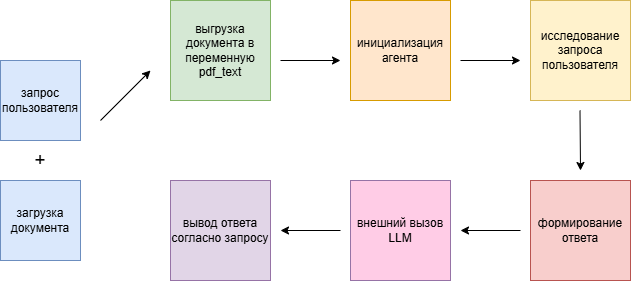

In [23]:
from IPython.display import Image
Image('Пайплайн.drawio.png')